In [ ]:
#Name: Angel Vasquez
#Lab Partner: Navpreet Kloy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Load the dataset
df = pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
# Display basic statistics for all features
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
# Separate independent variables (X) and target variable (y)
# X = all columns EXCEPT 'Outcome'
# y = 'Outcome'  (0 = No Diabetes, 1 = Has Diabetes)

x = df.drop(columns=['Outcome'])
y = df['Outcome']

print("Feature matrix X shape:", x.shape)
print("Target vector y shape: ", y.shape)
print("\nFeature columns:", list(x.columns))

Feature matrix X shape: (768, 8)
Target vector y shape:  (768,)

Feature columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [ ]:
# Split the dataset into Training Set and Test Set
# 75% training | 25% testing

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=0
)

print("Training samples:", x_train.shape[0])
print("Testing samples: ", x_test.shape[0])

Training samples: 576
Testing samples:  192


In [ ]:
# Feature Scaling — StandardScaler normalizes features to mean=0, std=1
# This is critical for Logistic Regression performance

from sklearn.preprocessing import StandardScaler

st_x = StandardScaler()
x_train = st_x.fit_transform(x_train)
x_test  = st_x.transform(x_test)

print("Feature scaling complete.")
print("Scaled x_train sample (first row):", x_train[0])

Feature scaling complete.
Scaled x_train sample (first row): [ 1.50755225 -1.01521454 -0.40451932 -1.31921491 -0.71823753 -1.22070104
 -0.98325882 -0.04863985]


In [ ]:
# Train the Logistic Regression classifier

from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(random_state=0)
classifier.fit(x_train, y_train)

LogisticRegression(random_state=0)

In [ ]:
# Predicting the test set results
y_pred = classifier.predict(x_test)

In [ ]:
# Confusion Matrix — shows True Positives, False Positives, etc.

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print("\n[TN  FP]")
print("[FN  TP]")

Confusion Matrix:
[[118  12]
 [ 26  36]]

[TN  FP]
[FN  TP]


In [ ]:
# Determine the model accuracy

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the model: {accuracy:.4f}  ({accuracy*100:.2f}%)")

Accuracy of the model: 0.8021  (80.21%)


In [ ]:
# Evaluate the model using Precision, Recall, and F1-Score

from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

Precision : 0.7500
Recall    : 0.5806
F1-Score  : 0.6545


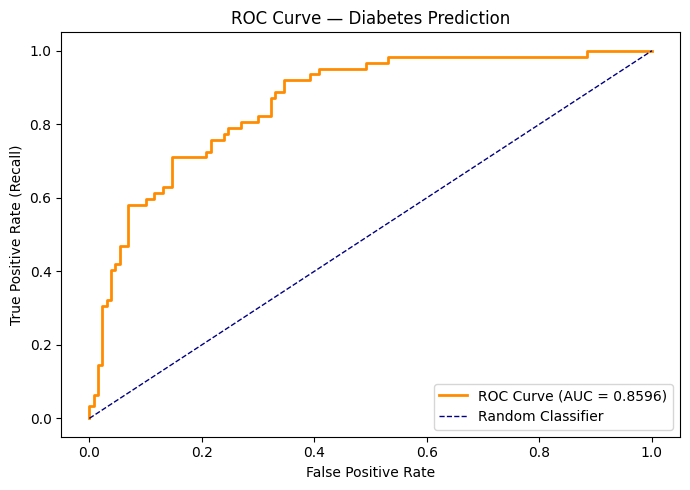

AUC Score: 0.8596


In [ ]:
#Curve and Score

from sklearn.metrics import roc_curve, roc_auc_score

y_prob = classifier.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Diabetes Prediction')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc:.4f}")

In [ ]:
# Enter new patient data and predict diabetes risk

while True:
    try:
        print("=" * 45)
        print("   Diabetes Risk Prediction — Enter Patient Data")
        print("=" * 45)

        pregnancies       = int(input("Pregnancies (number of times pregnant): "))
        glucose           = int(input("Glucose (plasma glucose concentration): "))
        blood_pressure    = int(input("BloodPressure (diastolic, mm Hg): "))
        skin_thickness    = int(input("SkinThickness (triceps skin fold, mm): "))
        insulin           = int(input("Insulin (2-hour serum insulin, mu U/ml): "))
        bmi               = float(input("BMI (body mass index): "))
        diabetes_pedigree = float(input("DiabetesPedigreeFunction: "))
        age               = int(input("Age (years): "))

        new_data_point = np.array([[pregnancies, glucose, blood_pressure,
                                    skin_thickness, insulin, bmi,
                                    diabetes_pedigree, age]])

        new_data_point_scaled = st_x.transform(new_data_point)
        prediction            = classifier.predict(new_data_point_scaled)
        probability           = classifier.predict_proba(new_data_point_scaled)[0]

        print("\n" + "-" * 45)
        if prediction[0] == 0:
            print("Prediction: No Diabetes Detected")
        else:
            print("Prediction: Diabetes Detected")

        print(f"P(No Diabetes) = {probability[0]:.4f}  ({probability[0]*100:.1f}%)")
        print(f"P(Diabetes)    = {probability[1]:.4f}  ({probability[1]*100:.1f}%)")
        print("-" * 45)

        break  # Exit loop if input is valid

    except ValueError:
        print("Invalid input. Please enter valid numeric values for all fields.")
    except Exception as e:
        print(f"An error occurred: {e}")

   Diabetes Risk Prediction — Enter Patient Data
Pregnancies (number of times pregnant): 31
Glucose (plasma glucose concentration): 321
BloodPressure (diastolic, mm Hg): 32
SkinThickness (triceps skin fold, mm): 34
Insulin (2-hour serum insulin, mu U/ml): 32
BMI (body mass index): 21
DiabetesPedigreeFunction: 34
Age (years): 21

---------------------------------------------
Prediction: Diabetes Detected
P(No Diabetes) = 0.0000  (0.0%)
P(Diabetes)    = 1.0000  (100.0%)
---------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
